# Einführung in Maschinelles Lernen

#### Leitidee
An KI führt in unserer Zeit kaum ein Weg mehr vorbei. Doch nicht immer wird KI für dort eingesetzt, wo sie wirklich geeignet ist. Beim Erstellen von KI eine Menge Entscheidungen von Menschen getroffen, was später für einen Laien kaum mehr sichtbar ist. Ziel dieser Lerneinheit ist es, maschinelles Lernen als Grundlage von KI kennenzulernen. Die Maschine "lernt" aus Daten, um auf Unbekanntes zu verallgemeinern. Dabei erarbeiten wir auch die Grenzen und Möglichkeiten von Mensch und Maschine beim Erstellen von KI.

#### Übergeordnete Lernziele
- Die SuS lernen, mithilfe einfacher Algorithmen maschinelles Lernen zu modellieren und evaluieren
- Die SuS können die Verlässlichkeit von KI-Ausgaben einschätzen und kritisch einordnen
- Die SuS verstehen den Zusammenhang zwischen Statistik und maschinellem Lernen

## Kapitel 0 Einführung in Maschinelles Lernen

#### Lernziele:
- Sie können den Begriff "Maschinelles Lernen" in eigenen Worten erklären
- Sie kennen den Unterschied zwischen schwacher und starker KI
- Sie wissen, was ein Modell im ML-Kontext ist

KI wird heute gerne als Heilsversprechen für vielerlei grössere und kleinere Probleme propagiert. Um einschätzen zu können, welche davon wahr sind und welche eher nicht, müssen wir uns zuerst mit den Grundlagen und wichtigen Begriffen vertraut machen.

### Künstliche Intelligenz vs. Maschinelles Lernen

**Künstliche Intelligenz (KI)** ist ein Oberbegriff für Techniken, die Maschinen "intelligent" erscheinen lassen. Auch ein klassischer Algorithmen und Programme wie Sie sie bereits kennen können benutzt werden, um eine Maschine "intelligent" wirken zu lassen.

**Maschinelles Lernen (ML)** ist ein Teilbereich der KI. Beim klassischen Programmieren schreibt ein Mensch explizite Regeln, die der Computer befolgt. Maschinelles Lernen grenzt sich dadurch ab, dass der Computer diese Regeln selbst ableitet, indem er Muster in Daten erkennt.

| | Klassische Programmierung | Maschinelles Lernen |
|---|---|---|
| Eingabe | Daten + Regeln | Daten (+ Ergebnisse) |
| Ausgabe | Ergebnis | Schätzung, Vorhersage |

Ein Beispiel: Statt einem Computer explizit zu sagen "Eine E-Mail ist Spam, wenn sie das Wort 'Gewinn' enthält", zeigt man ihm tausende Beispiele von Spam und normalen Mails und lässt ihn die Regeln selbst ableiten.

Wichtig beim ML: Es wird von bekannten Daten auf Unbekanntes verallgemeinert. Es ist daher wichtig, auch die Zuverlässigkeit dieser Verallgemeinerung zu prüfen. Dies betrachten wir später im Detail.

### Starke KI vs. Schwache KI

**Schwache KI:** Auf eine einzige Aufgabe spezialisiert. Beispiele: ein Schachprogramm, ein Bilderkennungssystem, ein Sprachübersetzer. Schwache KI kann in ihrem Spezialgebiet sehr gut, ja sogar besser als Menschen sein, scheitert aber ausserhalb davon vollständig. Das ist der aktuelle Stand der Technik.

**Starke KI (General AI):** Ein System, das beliebige intellektuelle Aufgaben so flexibel lösen kann wie ein Mensch. Starke KI existiert bisher nicht und ist Gegenstand aktiver Forschung und Debatte.

Beachte: Es können verschiedene schwache KI miteinander verknüpft werden, um komplexere Aufgaben zu erledigen. Dies kann den Anschein erwecken, dass die KI mehr als eine Aufgabe erledigen kann. Deshalb handelt es sich aber noch nicht um eine starke KI.

### Was ist ein Modell?

Ein **Modell** in ML ist eine ist ein Programm, welches Muster in Daten finden oder Entscheidungen treffen kann anhand der Daten, die es als "Training" erhalten hat. Es nimmt neue Daten als Eingaben entgegen und berechnet daraus eine Ausgabe.

In Kapitel 1 werden Sie Ihr erstes Modell kennenlernen: eine Gerade, die den (fiktiven?) Zusammenhang zwischen Lernzeit und Note beschreibt. Das ist bereits ein Modell im Sinne des maschinellen Lernens.

## Kapitel 1 Lineare Regression
#### Lernziele:
- Sie können erklären, was ein Feature und ein Label ist
- Sie können berechnen, ob ein linearer Zusammenhang zwischen zwei Variablen besteht
- Sie kennen eine Methode, um einen linearen Zusammenhang zwischen zwei Variablen für ML zu nutzen

Unsere allererste Methode für Maschinelles Lernen erarbeiten wir mithilfe eines fiktiven Fallbeispiels.
Stellen Sie sich vor, Sie hätten all ihre Freunde gefragt, wie lange diese für die letzte Informatikprüfung gelernt haben, und welche Note sie dabei erhalten haben.

Um ihren Aufwand zu optimieren (bzw. zu minimieren) möchten Sie anhand dieser Daten herausfinden, wie lange Sie wohl selbst für eine Informatikprüfung lernen müssen, um ihre Zielnote zu erhalten. (Natürlich sind alle Informatikprüfungen immer perfekt balanciert und gleich schwer.)

Wir benutzen dazu eine **lineare Regression**. Der Begriff *Regression* stammt aus der Statistik und bezeichnet Methoden zur Vorhersage einer **kontinuierlichen** Ausgabegrösse. Im Gegensatz dazu steht die *Klassifikation*, die diskrete Klassen vorhersagt (z.B. "bestanden" / "nicht bestanden"). Eine Note als Dezimalzahl vorherzusagen ist also ein Regressionsproblem, eine Ja/Nein-Entscheidung wäre Klassifikation.

### Fallstudie: Lernzeit und Note

Wir können unser Datenset zweidimensional abbilden. Eure Eingabevariable ist die Lernzeit. Im Machine Learning nennt man solche Eingabevariablen auch **Feature**.

Eure Ausgabe wäre dann eure Note.

Betrachten wir das Datenset:

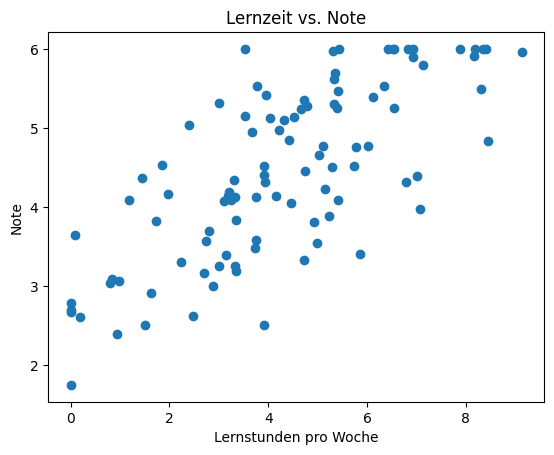

In [116]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression

# Fiktive Beispieldaten erstellen
X_raw, y_raw = make_regression(n_samples=100, n_features=1, noise=50, random_state=42)
lernstunden = (X_raw.flatten() * 2.5 + 4.5).clip(0, 15)
note_raw = y_raw
note = (note_raw - note_raw.mean()) / note_raw.std() * 1.2 + 4.5
note = note.clip(1.0, 6.0)

# Visualisierung
plt.scatter(lernstunden, note)
plt.xlabel("Lernstunden pro Woche")
plt.ylabel("Note")
plt.title("Lernzeit vs. Note")
plt.show()

Um zu wissen, ob das **Feature** auch ein geeigneter **Predictor** (Vorhersage) für eure Note ist, lohnt es sich, zunächst einmal eine einfache **statistische Korrelation** zu berechnen.

Korrelation ist eine Metrik, die besagt, wie stark sich zwei Variablen gemeinsam verändern, also in einer Wechselbeziehung zueinander stehen. Das bedeutet in unserem Fall, wir prüfen ob mehr Lernen tatsächlich auch eine bessere Note einbringt (Korrelation), oder die Note auch steigt, wenn sich die Lernzeit nicht verändert (keine Korrelation).

Beachte: Korrelation impliziert keine **Kausalität**. Nur weil zwei Merkmale einen statistischen Zusammenhang aufweisen, muss es dafür noch keinen Grund geben. Eine Kausalität müsste sorgfältig durch viele weitere Experimente belegt werden. 

Der **Korrelationskoeffizient** $r$ misst die Stärke des *linearen* Zusammenhangs zwischen zwei Variablen und nimmt Werte zwischen $-1$ und $+1$ an:

| $r$ | Bedeutung |
|-----|-----------|
| $r \approx +1$ | Starker positiver Zusammenhang: wenn X steigt, steigt Y |
| $r \approx -1$ | Starker negativer Zusammenhang: wenn X steigt, sinkt Y |
| $r \approx 0$  | Kein (linearer) Zusammenhang |

Als Faustregel gilt: $|r| > 0.7$ ist eine starke Korrelation, $|r| > 0.4$ eine moderate.

Wichtig: Korrelation misst nur **lineare** Zusammenhänge. Zwei Variablen können stark zusammenhängen, ohne dass $r$ das anzeigt, nämlich dann, wenn der Zusammenhang kurvenförmig ist.

In [117]:
# Korrelation: np.corrcoef gibt eine Korrelationsmatrix zurück
# corrcoef[0, 1] ist der Korrelationskoeffizient zwischen den beiden Variablen
r = np.corrcoef(lernstunden, note)[0, 1]
print(f"Korrelationskoeffizient r = {r:.2f}")

Korrelationskoeffizient r = 0.74


---
> **Aufgabe:** Denken Sie, dass Lernstunden eine geeignete Voraussage über die Note erlauben? Beziehen Sie Ihr neues Wissen über Korrelation in Ihre Antwort mit ein.


> **Aufgabe**: Oftmals muss man aus den vorhandenen Daten geeignete Features auswählen. Dafür kann man eine **Heatmap** erstellen, die die Korrelation zwischen jeweils zwei Datentypen zeigt. 
>
> Nehmen Sie an, Sie suchen ein Feature, um den Kaloriengehalt eines Cereals vorherzusagen. Eine Dokumentation der Daten finden sie [hier](https://www.kaggle.com/datasets/crawford/80-cereals/data). Betrachten Sie dazu die Heatmap unten. Welche Features bieten sich an und weshalb?

In [ ]:
#Nötige Installationen
%pip install -q kagglehub
%pip install -q seaborn


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


<Axes: >

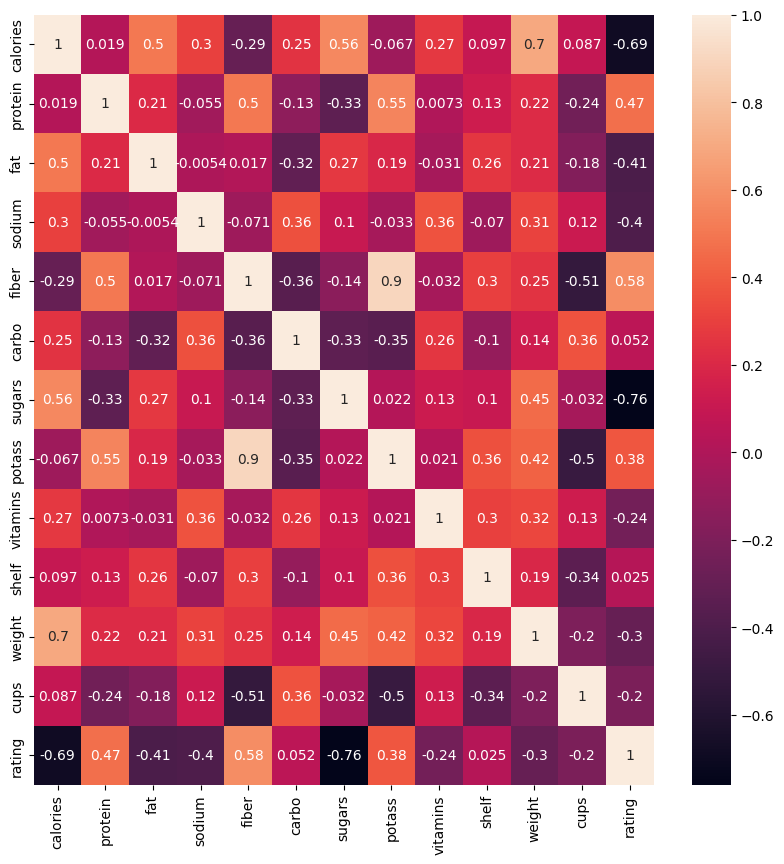

In [188]:
#Datenset von https://www.kaggle.com/datasets/crawford/80-cereals/data
import kagglehub
import numpy as np
import pandas as pd
from kagglehub import KaggleDatasetAdapter
import os
import seaborn as sns
import matplotlib.pyplot as plt

# Daten herunterladen
path = kagglehub.dataset_download("crawford/80-cereals")

# Die verschiedenen Datentypen
cereal = pd.read_csv(path+"/cereal.csv")
name = cereal['name'].to_numpy()
mfr = cereal['mfr'].to_numpy()
typ = cereal['type'].to_numpy()
cal = cereal['calories'].to_numpy()
prot = cereal['protein'].to_numpy()
fat = cereal['fat'].to_numpy()
sodium = cereal['sodium'].to_numpy()
fiber = cereal['fiber'].to_numpy()
carbs = cereal['carbo'].to_numpy()
sugars = cereal['sugars'].to_numpy()
potassium = cereal['potass'].to_numpy()
vitamins = cereal['vitamins'].to_numpy()
shelf = cereal['shelf'].to_numpy()
weight = cereal['weight'].to_numpy()
cups = cereal['cups'].to_numpy()
rating = cereal['rating'].to_numpy()

fig, ax = plt.subplots(figsize=(10,10)) 
sns.heatmap(cereal.select_dtypes('number').corr(), annot=True)

---

---
### Die erste Gleichung

**Annahme**: Wir nehmen hier eine kleine Abkürzung und gehen davon aus, dass sich unser Feature zur Vorhersage eignet. Nun benötigen wir eine Funktion, die diesen Zusammenhang auch ausdrücken kann.

Sei $Y$ unsere Vorhersage und $X$ unsere Eingabe. Dann suchen wir eine Funktion $f(X)$ so dass:

$$Y = f(X) + \epsilon$$
 wobei $\epsilon$ einen sogenannten Fehlerterm darstellt, schliesslich gibt es in unserem Modell auch noch einiges an Unsicherheit.

Wie finden wir nun $f(X)$? Da wir von einem linearen Zusammenhang ausgehen, können wir folgendes annehmen:
$$f(X) = \beta_1X + \beta_0$$

Durch die Annahme des linearen Zusammenhangs haben wir uns hier für ein **lineares Modell** entschieden. Wir sagen auch, Y wird **ungefähr modelliert** durch $f(X)$ und schreiben $Y \approx f(X)$ (dadurch kann der Fehlerterm weggelassen werden).

In der Praxis sind die Koeffizienten $\beta_0$ und $\beta_1$ natürlich nicht bekannt. Es geht also darum, geeignete Koeffizienten $\hat\beta_0$ und $\hat\beta_1$ zu finden, damit unsere Vorhersage, $\hat Y$, deren echten Wert wir auch nicht kennen, *möglichst genau* wird.

Das "Dach" (^) bei $\hat Y$, $\hat\beta_0$ und $\hat\beta_1$ kennzeichnet immer eine Schätzung oder Vorhersage, im Gegensatz zu den unbekannten, wahren Werten $Y, \beta_0, \beta_1$.

Begriffe wie *geeignet* und *möglichst genau* sind viel zu schwammig, um uns von technischem Nutzen zu sein.

### Kleinste Quadrate

Eine der bekanntesten, simplen Methoden um $\hat\beta_0$ und $\hat\beta_1$ zu schätzen, nennt sich "Kleinste Quadrate", oder auch "Least Squares".

Dazu benötigen wir unser Datenset. Wir nennen diese Daten **Trainingsdaten**, da unsere Schätzung auf ihnen beruht. Unser Modell wird also damit **trainiert**.

Das Ziel ist, diejenige Gerade zu finden, bei der die Abweichungen zwischen den echten Werten $y_i$ und den Vorhersagen $\hat{y}_i$ insgesamt möglichst klein sind. Diese Abweichungen nennen wir **Residuals**. Least Squares minimiert deren quadrierte Summe, die **Residual Sum of Squares (RSS)**:

$$RSS = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2 = \sum_{i=1}^{n}(y_i - \hat\beta_0 - \hat\beta_1 x_i)^2$$

Durch Ableiten nach $\hat\beta_0$ und $\hat\beta_1$ und Nullsetzen erhält man die optimalen Koeffizienten:

$$\hat\beta_1 = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^{n}(x_i - \bar{x})^2} \qquad \hat\beta_0 = \bar{y} - \hat\beta_1\bar{x}$$

wobei $\bar{x}$ und $\bar{y}$ die Mittelwerte der Trainingsdaten sind.

Wir stellen fest, dass für das **Training** die echten Werte von **y** benötigt werden.
Das bedeutet, dass wir für das Training der Linearen Regression nicht nur ein Datenset von Eingaben benötigen, sondern auch die dazugehörigen Ausgaben.
Während wir die Eingaben als Feature bezeichnen, wird die dazu passende Ausgabe **Label** genannt.

β₁= 0.3671
β₀= 2.8690
RSS = 53.6696


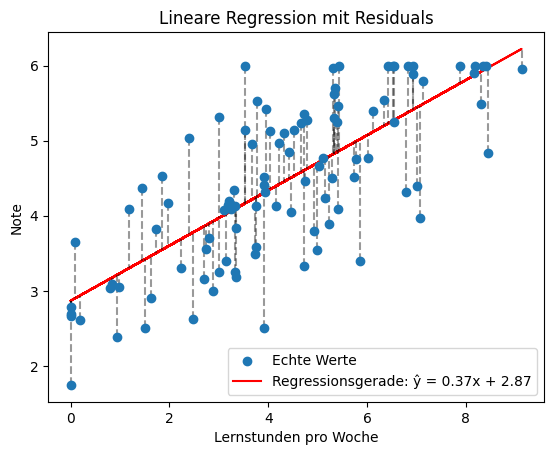

In [189]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Fiktive Beispieldaten erstellen
X_raw, y_raw = make_regression(n_samples=100, n_features=1, noise=50, random_state=42)
lernstunden = (X_raw.flatten() * 2.5 + 4.5).clip(0, 15)
note_raw = y_raw
note = (note_raw - note_raw.mean()) / note_raw.std() * 1.2 + 4.5
note = note.clip(1.0, 6.0)

# Trainingsdaten (X muss 2D sein für sklearn)
lernstunden = np.array(lernstunden).reshape(-1, 1)
note = np.array(note)

# Modell trainieren (sklearn berechnet Least Squares intern)
modell = LinearRegression()
modell.fit(lernstunden, note)

beta_1, beta_0 = modell.coef_[0], modell.intercept_
y_pred = modell.predict(lernstunden)

# RSS berechnen
rss = np.sum((note - y_pred)**2)
print(f"β₁= {beta_1:.4f}")
print(f"β₀= {beta_0:.4f}")
print(f"RSS = {rss:.4f}")

# Regressionsgerade und Residuals visualisieren
plt.scatter(lernstunden, note, label="Echte Werte", zorder=5)
plt.plot(lernstunden, y_pred, color='red',
         label=f"Regressionsgerade: ŷ = {beta_1:.2f}x + {beta_0:.2f}")
for x, y, yp in zip(lernstunden.flatten(), note, y_pred):
    plt.plot([x, x], [y, yp], 'k--', alpha=0.4)  # Residuals einzeichnen
plt.xlabel("Lernstunden pro Woche")
plt.ylabel("Note")
plt.legend()
plt.title("Lineare Regression mit Residuals")
plt.show()

Die gestrichelten Linien zeigen die **Residuals**, also die vertikalen Abstände zwischen den echten Datenpunkten und der Regressionsgerade. Least Squares findet genau die Gerade, bei der die Summe dieser quadrierten Abstände minimal ist.

---
> **Aufgabe**: Was bedeuten die Koeffizienten in Bezug auf die Gerade?

> **Aufgabe:** Weshalb minimiert man die *quadrierten* Residuals und nicht deren Absolutbeträge?

> **Aufgabe:** Wie viele Trainingsdaten braucht es?
---

---
**Vorhersage (Prediction)**

Die Vorhersage für einen neuen Eingabewert $x_{neu}$ schreiben wir als:

$$\hat{y}_{neu} = \hat\beta_0 + \hat\beta_1 \cdot x_{neu}$$

Zur Erinnerung: Das "Dach" (^) kennzeichnet immer eine Schätzung oder Vorhersage, im Gegensatz zum unbekannten, wahren Wert $y$.

In [121]:
stunden = 5
vorhersage = modell.predict([[stunden]])
print(f"Vorhergesagte Note bei {stunden}h/Woche: {vorhersage[0]:.2f}")

Vorhergesagte Note bei 5h/Woche: 4.70


---
> **Aufgabe:** Benutzen Sie das Modell für einige Vorhersagen. Stimmen sie mit Ihren Erwartungen überein? Notieren Sie sich Ihren geschätzten Wert und die Vorhersage des Modells und vergleichen Sie sie.

> **Aufgabe:** Was sagt das Modell, wenn Sie eine ganze Arbeitswoche nur lernen? Überlegen Sie, was das Modell als Eingabe bekommen hat und reflektieren Sie, wie dieser Wert zustande kommt. Wie würden Sie damit umgehen?

> **Aufgabe:** *(Code-Vorlage weiter unten)* Wenden Sie sich erneut dem Cereal-Datenset zu. Sie möchten immer noch den Kaloriengehalt von Cereals "voraussagen". Lineare Regression funktioniert nämlich auch mit mehr als einem Feature. 
> 
> Die Formel dafür benötigt etwas Wissen über Lineare Algebra [Formel](https://en.wikipedia.org/wiki/Linear_least_squares#Basic_formulation). Scikit-Learn übernimmt das aber für Sie. Schauen Sie sich die Dokumentation an und erstellen Sie ein Modell mit mehreren Features, die Sie aus der Heatmap auswählen können: [Dokumentation Lineare Regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html).

> **Aufgabe**: Berechnen Sie zusätzlich den RSS wie oben.


In [201]:
feature1 = [] #Hier ein Feature wählen
feature2 = [] #Hier ein Feature wählen
# Sie können auch noch weitere Features hinzufügen
# Diese Zeile für mehr Features anpassen
X_cereal = [[f1, f2] for (f1, f2) in zip(feature1, feature2)]
y_cereal = cal

# Modell trainieren (sklearn berechnet Least Squares intern)

# RSS berechnen


___

---
## Kapitel 2 Modelle Evaluieren
#### Lernziele
- Sie erklären, weshalb Datensets aufgetrennt werden sollen
- Sie kennen verschiedene Metriken, um die Qualität eines Modells zu evaluieren

Wir wollen wissen, ob unser Modell überzeugt. 
Dafür benötigen wir einen Weg, um die Qualität des Modells zufriedenstellend messen zu können.
Ähnlich wie beim Training des Modells wollen wir Vorhersagen mit den echten Labels vergleichen und schauen, wie nahe sie zusammen liegen.

Natürlich dürfen die Daten, die wir zum Evaluieren benutzen nicht dieselben sein wie im Training.
Anonsten würden wir nur testen, wie gut unser Modell die vorhandenen Daten "auswendig gelernt" hat.
Dadurch wissen wir aber noch nicht, wie gut unser Modell "im echten Leben" Vorhersagen trifft.

Es ist deshalb wichtig dass man von einem gegebenen Datensatz von Anfang an einen gewissen Prozentsatz zurückbehält.
Üblich sind 20-30% für den Testdatensatz. Diese zurückgehaltenen Daten werden nicht zum Training verwendet.
Wir nennen sie stattdessen **Testdaten**, um sie klar von den Trainingsdaten abzugrenzen.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Daten aufteilen: 80% Training, 20% Test
X_train, X_test, y_train, y_test = train_test_split(
    lernstunden, note, test_size=0.2, random_state=42
)

# Modell nur auf Trainingsdaten trainieren
modell2 = LinearRegression()
modell2.fit(X_train, y_train)
#Neue Koeffizienten
beta_12, beta_02 = modell2.coef_[0], modell2.intercept_
y_pred2 = modell2.predict(X_train)
# RSS berechnen
rss_train = np.sum((y_train - y_pred2)**2)
print(f"β₁ (Steigung)        = {beta_12:.4f}")
print(f"β₀ (Achsenabschnitt) = {beta_02:.4f}")
print(f"RSS                  = {rss_train:.4f}")

# Vorhersagen auf Testdaten (Daten, die das Modell nie gesehen hat)
y_pred_test = modell2.predict(X_test)


β₁ (Steigung)        = 0.3775
β₀ (Achsenabschnitt) = 2.7450
RSS                  = 42.2106


`random_state=42` sorgt dafür, dass die Aufteilung bei jedem Ausführen gleich ist und die Ergebnisse reproduzierbar bleiben.

---
> **Aufgabe**: Die Koeffizienten im neuen Modell mit Trainingsdaten unterscheiden sich von den Koeffizienten im ersten Modell. Woran liegt das? Welches Modell würden Sie als zuverlässiger einschätzen?

> **Aufgabe:** Testen Sie am Beispiel oben einige unterschiedliche Aufteilungen und Random States und beobachten Sie, wie sich die Koeffizienten verändern. Woher kommen die Unterschiede?

> **Aufgabe**: Bearbeiten Sie Ihr Modell zum Datenset *Cereal* so, dass ebenfalls nur auf einem Trainingsdatenset trainiert wird und ein Teil der Daten zurückbehalten wird.
---

Es gibt verschiedene statistische Metriken, um die Qualität eines Linearen Regressors zu berechnen.
Wir betrachten zuerst einmal zwei einfachere Metriken mit ihren Vor- und Nachteilen.

#### Mean Absolute Error (MAE)

Der **mittlere absolute Fehler** berechnet den Durchschnitt der absoluten Abweichungen zwischen echten Werten und Vorhersagen:

$$MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|$$

- **Vorteil:** Gewichtet alle Fehler gleich stark und ist intuitiv lesbar. Ein MAE von 0.3 bedeutet: das Modell liegt im Schnitt um 0.3 Noten daneben.
- **Vorteil:** Robust gegenüber **Ausreissern** (einzelne, weit entfernte Datenpunkte), weil deren Fehler gleich gewichtet wird wie alle anderen.
- **Nachteil:** Der Absolutbetrag ist bei 0 nicht differenzierbar, was die mathematische Optimierung erschwert.

In [123]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae  = mean_absolute_error(y_test, y_pred_test)

print(f"MAE  = {mae:.4f}")
print(f"Mit unseren gegebenen Testdaten liegt das Modell im Schnitt um {mae:.4f} Noten daneben")

MAE  = 0.6601
Mit unseren gegebenen Testdaten liegt das Modell im Schnitt um 0.6601 Noten daneben


#### Mean Squared Error (MSE)

Der **mittlere quadratische Fehler** quadriert die Abweichungen, bevor er den Durchschnitt bildet:

$$MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

Sie erkennen die Verwandtschaft mit dem RSS: $MSE = \frac{RSS}{n}$.

- **Vorteil:** Mathematisch gut handhabbar und ableitbar, was analytische Lösungen ermöglicht.
- **Vorteil:** Bestraft grosse Fehler stärker, was je nach Kontext erwünscht ist.
- **Nachteil:** Die Einheit wird quadriert (z.B. Note²), was die direkte Interpretation erschwert.

Ein **Ausreisser** ist ein Datenpunkt, der stark vom Rest abweicht, z.B. jemand der 11 Stunden lernt, aber trotzdem eine sehr schlechte Note bekommt. Stell dir vor, das Modell macht neun Fehler von je 0.1 und einen einzigen Fehler von 2.0:

| Fehlermass | Berechnung | Ergebnis |
|---|---|---|
| MAE | $\frac{9 \cdot 0.1 + 1 \cdot 2.0}{10}$ | $0.29$ |
| MSE | $\frac{9 \cdot 0.01 + 1 \cdot 4.0}{10}$ | $0.41$ |

Der eine grosse Fehler dominiert den MSE viel stärker als den MAE, weil er quadriert wird ($2.0^2 = 4.0$). Man sagt: MSE ist empfindlicher gegenüber Ausreissern.

Um die Einheitenproblematik des MSE zu umgehen, nimmt man häufig den **RMSE** (Root Mean Squared Error), auch geschätzter Standardfehler der Residuen genannt:

$$RMSE = \sqrt{MSE}$$

Der RMSE hat wieder dieselbe Einheit wie die Zielvariable, bestraft Ausreisser aber immer noch stärker.

| Fehlermass | Berechnung | Ergebnis |
|---|---|---|
| MAE | $\frac{9 \cdot 0.1 + 1 \cdot 2.0}{10}$ | $0.29$ |
| MSE | $\frac{9 \cdot 0.01 + 1 \cdot 4.0}{10}$ | $0.41$ |
| RMSE | $\sqrt{\frac{9 \cdot 0.01 + 1 \cdot 4.0}{10}}$ | $0.64$ |

In [124]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae  = mean_absolute_error(y_test, y_pred_test)
mse  = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)

print(f"MAE  = {mae:.4f}")
print(f"MSE  = {mse:.4f}")
print(f"RMSE = {rmse:.4f}")

MAE  = 0.6601
MSE  = 0.6070
RMSE = 0.7791


Grundsätzlich benutzen verschiedene Metriken verschiedene Verteilungen, in Kombination mit deren Durchschnitt, Median, Varianz oder Abweichung.

Diese verschiedenen Bestandteile können dabei auch je nach Methode unterschiedlich gewichtet werden.
Entsprechend dieser Auswahl werden gewisse Arten von Fehlern stärker bestraft als andere.

**Die Wahl der Metrik trägt also fundamental dazu bei, als wie gut das Modell in einem gewissen Kontext wahrgenommen wird.
Gleichzeitig kann die Wahl der Metrik auch der Verschleierung gewisser Schwächen des Modells dienen.**

Unser Modell ist sehr simpel mit nur einem Feature. Zudem sind unsere Daten künstlich generiert. Deshalb gibt es an diesem Punkt noch keine Möglichkeit, mithilfe der gelernten Metriken zu **optimieren**, so wie das normalerweise gemacht würde.

Wir können uns aber mit einem "Dummy"-Modell vergleichen, welches sklearn zur Verfügung stellt. Dieses verfolgt eine deterministische Strategie: Es gibt zum Beispiel immer den Durchschnitt oder Median eines Datensets zurück.

In [208]:
import numpy as np
from sklearn.dummy import DummyRegressor

dummy_regr = DummyRegressor(strategy="mean")

dummy_regr.fit(X_train, y_train)

# Vorhersage auf Testdaten
y_dummy = dummy_regr.predict(X_test)

# Fehlermetriken berechnen
mae_dummy  = mean_absolute_error(y_test, y_dummy)
mse_dummy  = mean_squared_error(y_test, y_dummy)
rmse_dummy = np.sqrt(mse_dummy)

print(f"MAE  = {mae_dummy:.4f}")
print(f"MSE  = {mse_dummy:.4f}")
print(f"RMSE = {rmse_dummy:.4f}")

MAE  = 13.4016
MSE  = 303.9909
RMSE = 17.4353


---
> **Aufgabe:** Erstellen Sie zusätzlich einen Dummy-Regressor, welcher immer den Median des Datensets zurückgibt. Welches der Modelle performt am Besten?

In [202]:
#Dummy Regressor mit Median

> **Aufgabe** Arbeiten Sie zu zweit: Finden Sie mithilfe der oben vorgestellten Metriken das beste Modell *Cereal*, welches **2 Features** benutzt (Challenge: **3 Features**). Welche Features eignen sich am Besten und welche Scores können Sie erreichen? Nutzen Sie einen Train-Test-Split von 80/20.

In [206]:
# Modell Cereal mit verschiedenen Features durchtesten

___

---
## Kapitel 3 Classifier
#### Lernziele:
- Sie können den Unterschied zwischen Regression und Klassifikation erklären
- Sie verstehen, wie K-Nearest Neighbors funktioniert (Distanz, Mehrheitsentscheid)
- Sie wissen, was eine Decision Boundary ist und wie k sie beeinflusst
- Sie können eine Confusion Matrix lesen und FP/FN erklären
- Sie können Accuracy, Precision und Recall berechnen und wissen, wann Sie welche Metrik verwenden

Lineare Regression ist in der Lage, uns eine quantitative Vorhersage für eine Eingabe zu geben.
Manchmal benötigen wir jedoch eine **qualitative**, oder **kategorische** Antwort.
Diesen Prozess nennt man Klassifizierung, die dazugehörigen Modelle Classifier.

Beispiel: Wir sagen vorher, ob Sie die Prüfung bestehen oder nicht. Features sind wie lange Sie gelernt haben und wie häufig Sie sich im Unterricht gemeldet haben.

In der idealen Welt wäre die Lösung einfach: Für eine neue Beobachtung $x_0$ berechnen wir für jede mögliche Klasse $j$ die **bedingte Wahrscheinlichkeit**

$$\Pr(Y = j \mid X = x_0)$$

das heisst: "Wie wahrscheinlich ist es, dass diese Beobachtung zur Klasse $j$ gehört, unter Betrachtung ihrer Features?" Dann ordnen wir $x_0$ einfach der Klasse mit der höchsten Wahrscheinlichkeit zu. Diesen theoretisch optimalen Classifier nennt man **Bayes Classifier**; er minimiert die Fehlerrate unter allen möglichen Classifiern.

Das Problem: Um $\Pr(Y = j \mid X = x_0)$ exakt zu berechnen, müsste man die **wahre Verteilung** der Daten kennen, also wissen, wie genau sich Lernstunden und mündliche Beteiligung jedes einzelnen auf seine Note auswirkt. Wenn wir das wüssten, müssten wir kein maschinelles Lernen benutzen. Wir haben aber nur eine begrenzte Stichprobe an Trainingsdaten zur Verfügung.

Also brauchen wir eine Methode, die diese Wahrscheinlichkeit aus den Daten **schätzt**.

### K-Nearest Neighbors (KNN)

KNN ist genau diese Schätzmethode. Anstatt die wahre Wahrscheinlichkeit $\Pr(Y = j \mid X = x_0)$ zu kennen, **schätzen** wir sie aus den k nächsten Nachbarn:

$$\Pr(Y = j \mid X = x_0) \approx \frac{1}{K} \sum_{i \in \mathcal{N}_0} \mathbf{1}(y_i = j)$$

Die Schreibweise erklärt sich wie folgt:

- $\mathcal{N}_0$ ist die Menge der $K$ nächsten Nachbarn von $x_0$
- $\mathbf{1}(y_i = j)$ ist eine sogenannte **Indikatorfunktion**: sie gibt 1 zurück, wenn Nachbar $i$ zur Klasse $j$ gehört, und sonst 0
- Der ganze Ausdruck zählt also: **Wie viele der $K$ nächsten Nachbarn gehören zur Klasse $j$?** — und teilt durch $K$

Das ergibt eine Schätzung für die Wahrscheinlichkeit. KNN weist $x_0$ dann der Klasse mit der höchsten geschätzten Wahrscheinlichkeit zu. Gegeben einen neuen, unbekannten Datenpunkt, schaut also das Modell: Welche k Punkte im Trainingsdatensatz liegen am nächsten? Welche Klasse haben die meisten davon? Das wird die Vorhersage.

**Beispiel:** $K = 5$, drei Nachbarn haben bestanden, zwei nicht → $\hat{P}(\text{bestanden}) = \frac{3}{5} = 0.6$ → Vorhersage: bestanden.



Die **Nähe** zweier Punkte wird über die **euklidische Distanz** gemessen — dieselbe Formel wie beim Abstand zweier Punkte in der Geometrie:

$$d(A, B) = \sqrt{\sum_{j=1}^{p}(A_j - B_j)^2}$$

Bei zwei Features ($p = 2$, z.B. Lernstunden und Schlafstunden) vereinfacht sich das zu:

$$d(A, B) = \sqrt{(A_1 - B_1)^2 + (A_2 - B_2)^2}$$

#### Fiktive Fallstudie: Prüfung bestanden?

Wir erweitern unser fiktives Beispiel aus Kapitel 1. Anstatt eine Note vorherzusagen, wollen wir nun klassifizieren: Hat jemand die Prüfung **bestanden** oder **nicht bestanden**?

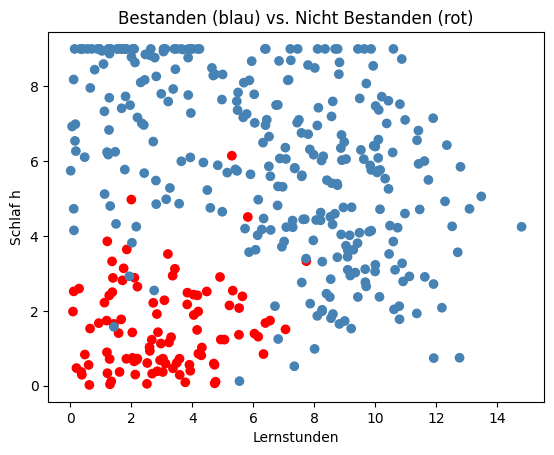

In [210]:
# Fiktive Beispieldaten erstellen
from sklearn.datasets import make_blobs
X_raw, y_raw = make_blobs(n_samples=400, centers=4, n_features=2, cluster_std= 2,
                  random_state=20)
lern_class = (abs(X_raw[:,0])).clip(0, 15)
sleep_class = (abs(X_raw[:, 1])).clip(0, 9)
resultat = ["Nicht Bestanden" if y == 3 else "Bestanden" for y in y_raw]

# Visualisierung
plt.scatter(lern_class, sleep_class, c=['red' if (y == "Nicht Bestanden") else 'steelblue' for y in resultat])
plt.xlabel("Lernstunden")
plt.ylabel("Schlaf h")
plt.title("Bestanden (blau) vs. Nicht Bestanden (rot)")
plt.show()

Auf dieses Datenset können wir den früher beschriebenen Algorithmus der k-nächsten Nachbarn anwenden:

In [211]:
from sklearn.neighbors import KNeighborsClassifier
# Formatieren der Daten für das Training
X = [[l, s] for (l, s) in zip(lern_class, sleep_class)]
X_train, X_test, y_train, y_test = train_test_split(
    X, resultat, test_size=0.3, random_state=1
)
# k=3: schaue die 3 nächsten Nachbarn an (heisst hier n_neighbors)
modell = KNeighborsClassifier(n_neighbors=20)
modell.fit(X_train, y_train)



,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",20
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


Betrachten wir nun, was das Modell vorhersagt für folgende Beispiele:
- Jemand, der gar nicht geschlafen und gar nicht gelernt hat
- Jemand mit 4h Schlaf und 3 Lernstunden
- Jemand mit 8h Schlaf und 6 Lernstunden

In [212]:
vorhersage1 = modell.predict([[0, 0]])
vorhersage2 = modell.predict([[4, 3]])
vorhersage3 = modell.predict([[8, 6]])
print(vorhersage1, vorhersage2, vorhersage3)

['Nicht Bestanden'] ['Nicht Bestanden'] ['Bestanden']


### Decision Boundaries

Im zweidimensionalen Merkmalsraum lässt sich das Modell visualisieren. Die **Decision Boundary** (Entscheidungslinie) ist die Trennlinie, die das Modell zwischen den Klassen zieht. Alles auf einer Seite wird als eine Klasse vorhergesagt, alles auf der anderen Seite als die andere.

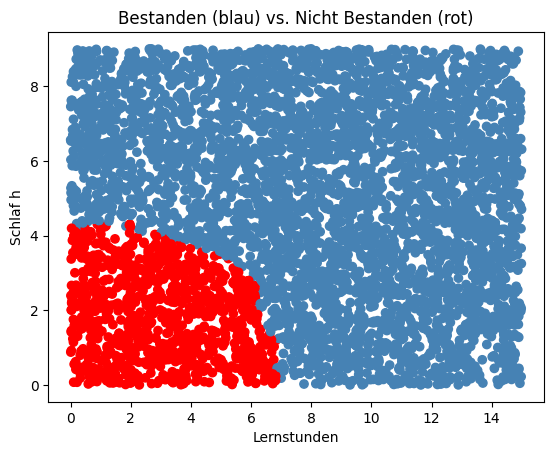

In [213]:
import random
l = [random.random()*15 for _ in range(5000)]
s = [random.random()*9 for _ in range(5000)]
pred = [modell.predict([[a,b]]) for (a, b) in zip(l,s)]
plt.scatter(l, s, c=['red' if (p == "Nicht Bestanden") else 'steelblue' for p in pred])
plt.xlabel("Lernstunden")
plt.ylabel("Schlaf h")
plt.title("Bestanden (blau) vs. Nicht Bestanden (rot)")
plt.show()

#### Einfluss von k

Der Parameter k ist entscheidend. Ein kleines k reagiert empfindlich auf jeden einzelnen Trainingspunkt, ein grosses k glättet die Grenze, glättet damit aber auch lokale Details.
| k | Verhalten |
|---|-----------|
| k = 1 | **Overfitting**: übernimmt die Antwort vom nächsten Nachbar, "abschreiben" |
| k = n | **Underfitting**: ungenau, gibt die "Mehrheitsmeinung" aller Datenpunkte aus |
| k dazwischen | ideal, oft mit **Fehlermetriken** bestimmt |

---
> **Aufgabe**: Verändere das aktuelle Modell mit verschiedenen Parametern von k. Welchen Veränderungen beobachten Sie?
---

### Confusion Matrix, False Positive und False Negative

Bei der linearen Regression haben wir MAE und RMSE verwendet. Für Classifier reicht eine einzige Zahl oft nicht, denn es kommt darauf an, **welche Art von Fehler** das Modell macht.

| | Tatsächlich: Bestanden | Tatsächlich: Nicht Bestanden |
|---|---|---|
| **Vorhergesagt: Bestanden** | True Positive (TP) | False Positive (FP) |
| **Vorhergesagt: Nicht Bestanden** | False Negative (FN) | True Negative (TN) |

- **True Positive (TP):** Bestanden korrekt als bestanden erkannt
- **True Negative (TN):** Nicht bestanden korrekt als nicht bestanden erkannt
- **False Positive (FP):** Nicht bestanden fälschlicherweise als bestanden markiert
- **False Negative (FN):** Bestanden fälschlicherweise als nicht bestanden markiert

Der Begriff *Positiv* bezeichnet dabei immer die Klasse, die das Modell "ausruft" (z.B. Spam, Krank, Bestanden). Welcher Fehler schlimmer ist, hängt vom Kontext ab: Bei einer Krebsdiagnose ist ein FN (Krebs übersehen) viel gefährlicher als ein FP (gesund, aber nochmals untersucht).

In [214]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, modell.predict(X_test)))

[[88  1]
 [ 4 27]]


### Accuracy, Precision, Recall und F1

Aus der Confusion Matrix lassen sich Metriken ableiten, die verschiedene Aspekte des Modells messen:

**Accuracy**: Wie oft hat das Modell insgesamt recht?

$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

- **Vorteil:** Einfach zu verstehen
- **Nachteil:** Irreführend bei unbalancierten Klassen (z.B. 95% der E-Mails sind kein Spam, aber ein Modell, das immer "kein Spam" sagt, hätte 95% Accuracy, wäre aber nutzlos)

**Precision**: Wenn das Modell "Positiv" sagt, wie oft stimmt das?

$$\text{Precision} = \frac{TP}{TP + FP}$$

**Recall** (auch: "Sensitivity"): Wie viele der tatsächlich positiven Fälle findet das Modell?

$$\text{Recall} = \frac{TP}{TP + FN}$$

Precision und Recall stehen oft in einem Spannungsverhältnis: Ein Modell, das sehr selten "Alarm schlägt", hat hohe Precision, aber tiefen Recall (es verpasst viele Fälle).

**F1-Score**: aus Precision und Recall, nützlich wenn beide gleichzeitig wichtig sind:

$$F_1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$

In [195]:
from sklearn.metrics import classification_report

print(classification_report(y_test, modell.predict(X_test),
      target_names=["Nicht bestanden", "Bestanden"]))

                 precision    recall  f1-score   support

Nicht bestanden       0.97      0.97      0.97       149
      Bestanden       0.92      0.90      0.91        51

       accuracy                           0.95       200
      macro avg       0.94      0.94      0.94       200
   weighted avg       0.95      0.95      0.95       200



---
> **Aufgabe**: Überlege dir 3 verschiedene Beispiele von Classifier-Problemen. Wo würdest du welche Metrik einsetzen, und weshalb?
---

## Nützliche Links
Installieren auf dem eigenen Gerät mit Virtual Environment:
- [(https://snarky.ca/why-you-should-use-python-m-pip/)](https://snarky.ca/why-you-should-use-python-m-pip/)
- [(https://scikit-learn.org/stable/install.html)](https://scikit-learn.org/stable/install.html)